# Diamonds価格分析 — v020-exp-05

## 分析計画
対象は指定のKaggle公開データのみ。API検索・ファイル一覧・原本取得を先に確認し、SHA-256と取得日時を残す。分析対象の単位・定義の確度をmanifestに分離する。

1. 欠測・重複・ゼロ寸法・非現実的寸法・カテゴリ逸脱を検査し、除外基準と行数を記録する。高価格・大重量だけでは誤りと断定しない。
2. 価格分布、重量と価格の図、品質ごとの無調整集計、Pearson/Spearman関連を調べる。
3. 再現可能な分割でlog価格の重量のみ・品質追加・寸法追加モデルを比較する。重量の非線形性を考慮し、条件調整後の関連と無調整の違いを説明する。
4. 重複・外れ値除外・重量範囲・モデル仕様の感度分析を実施する。結果を読み直して必要な追加依頼を最大3回実行する。
5. 全コードを上から再実行し、根拠manifest、visual_audit=True、lifecycle状態を記録する。

## 因果・適用範囲
観察データ内の記述的・関連的分析であり、処置効果ではない。年代・市場・販売条件・選択過程が不明なら現在の市場価格へ外挿しない。外部CSVミラーは使わない。秘密情報は表示しない。

## 実行経路
分析とKaggle SDK呼出しはJupyter MCPのexecute_cellのみ。ターゲットNotebookの構成・追記はproject_manager.enqueue_writeを用いる。MCPのネイティブ実行・出力保存はtransportが担当する。kernel内から同一kernelへ再入してmcp_gateway.run_and_recordを呼ぶ構成は採用しない（対応する同期MCPClientがkernelに供給されていないため）。偽のexecute/evalクライアントは使わない。


## 外部SDK互換性記録
初回の取得セルはinstalled KaggleApiにdataset_viewが存在しないためAttributeErrorで停止した（認証情報を含む例外本文は非表示）。dataset_listで対象slugは確認できている。SDKの公開dataset_metadata(dataset, path)に置換して再試行する。Jupytermindの不具合ではなくKaggle SDKメソッド差異。外部ソースへの切替はしていない。失敗状態は初期化セルからの再実行で新しい試行としてregister_runし直す。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, warnings, inspect
from datetime import datetime, timezone
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import nbformat, numpy as np, pandas as pd
from IPython.display import display
from ai_data_scientist import project_manager as pm, lifecycle
from ai_data_scientist.language_router import detect_language
RUN_ID = 'v020-exp-05'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-05-diamonds')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
language = detect_language('Diamondsデータの価格の違いを日本語で分析してください')
phase_log = []
@contextlib.contextmanager
def phase(label, writing=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行の取消が要求されています')
    start = lifecycle.mark_write_start if writing else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if writing else lifecycle.mark_execution_end
    start(RUN_ID)
    phase_log.append({'phase': label, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase': label, 'event': 'failed', 'utc': datetime.now(timezone.utc).isoformat()})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': label, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
print({'run_id': RUN_ID, 'language': language, 'state': asdict(lifecycle.get_run_status(RUN_ID))})


{'run_id': 'v020-exp-05', 'language': 'ja', 'state': {'run_id': 'v020-exp-05', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-05-diamonds/notebooks/kaggle-v020-kaggle-exp-05-diamonds.ipynb', 'reason': None}}


In [2]:
from contextlib import redirect_stdout, redirect_stderr
with phase('Kaggle公開データ検索・取得'):
    # SDK出力や例外本文に認証情報が混入しないよう表示を制限する。
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            found = api.dataset_list(search='diamonds', page=1)
        refs = [str(item.ref) for item in found]
        slug = 'shivam2503/diamonds'
        print('Kaggle検索結果(refのみ):', refs)
        if slug not in refs:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                exact = api.dataset_list(search='shivam2503 diamonds', page=1)
            refs += [str(item.ref) for item in exact]
        if slug not in refs:
            raise LookupError('指定slugをKaggle API検索で確認できないため外部フォールバックせず停止')
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            listing = api.dataset_list_files(slug)
            metadata_path = api.dataset_metadata(slug, path=str(data_dir))
        metadata = json.loads(Path(metadata_path).read_text(encoding='utf-8'))
        file_names = [str(f.name) for f in listing.files]
        print('slug:', slug, 'files:', file_names)
        if 'diamonds.csv' not in file_names:
            raise LookupError('diamonds.csvがAPIファイル一覧にないため停止')
        csv_path = data_dir / 'diamonds.csv'
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            api.dataset_download_file(slug, 'diamonds.csv', path=str(data_dir), force=True, quiet=True)
        if not csv_path.exists():
            import zipfile
            archive = data_dir / 'diamonds.csv.zip'
            if not archive.exists():
                raise FileNotFoundError('取得ファイルが存在しない')
            with zipfile.ZipFile(archive) as zf:
                names = zf.namelist()
                if names != ['diamonds.csv']:
                    raise ValueError('想定外のZIP内容')
                csv_path.write_bytes(zf.read('diamonds.csv'))
        provenance = {
            'owner_dataset_slug': slug, 'filename': 'diamonds.csv',
            'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
            'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(),
            'source_url': 'https://www.kaggle.com/datasets/' + slug,
        }
        assert provenance['sha256'] == 'fc2f171cc18eae2138d01dcca7179db3bb30ff047dceae4467a056d52133810a', '原本SHA-256が変わったため結果を再評価してください'
        description = str(metadata['info']['description'])
        print('PROVENANCE=' + json.dumps(provenance, ensure_ascii=False))
        print('Kaggle APIデータ説明:\n' + description[:16000])
        print('SDK dataset_download_file署名:', inspect.signature(api.dataset_download_file))
    except Exception as exc:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Kaggle API取得停止: ' + type(exc).__name__ + '。秘密情報保護のため例外本文は非表示。外部CSV未使用。') from None


Kaggle検索結果(refのみ): ['shivam2503/diamonds', 'nancyalaswad90/diamonds-prices', 'joebeachcapital/diamonds', 'ayeshaseherr/diamonds', 'resulcaliskan/diamonds', 'ulrikthygepedersen/diamonds', 'amirhosseinmirzaie/diamonds-price-dataset', 'miguelcorraljr/brilliant-diamonds', 'sahilnbajaj/diamonds-sale-data', 'swatikhedekar/price-prediction-of-diamond', 'harshitlakhani/natural-diamonds-prices-images', 'hrokrin/the-largest-diamond-dataset-currely-on-kaggle', 'natedir/diamonds', 'aayushpurswani/diamond-images-dataset', 'vittoriogiatti/diamondprices', 'soumyakushwaha/gemstone', 'willianoliveiragibin/type-of-the-diamond', 'ltrahul/diamonds-dataset', 'lovishbansal123/diamond-dataset', 'hosseinah1/poker-game-dataset']
slug: shivam2503/diamonds files: ['diamonds.csv']
PROVENANCE={"owner_dataset_slug": "shivam2503/diamonds", "filename": "diamonds.csv", "retrieved_at_utc": "2026-10-01T16:18:00.043087+00:00", "sha256": "fc2f171cc18eae2138d01dcca7179db3bb30ff047dceae4467a056d52133810a", "source_url": "ht

## データ定義・前提と品質検査
APIの原本説明を優先する。未確認の単位・母集団・時点はunknown/inferredのまま記録する。価格範囲の端を機械的に除外せず、明らかな寸法不整合と統計的な裾を分離する。

In [3]:
from ai_data_scientist.ingestion import SourceSpec, ingest
from ai_data_scientist.cleaning import clean_dataset
from ai_data_scientist.eda import explore
from ai_data_scientist.data_definition import FieldValue, build_manifest
from ai_data_scientist.analysis_assumptions import Assumption, AnalysisAssumptionManifest, check_manifest
from ai_data_scientist.data_quality import detect_anomalies
with phase('データ定義・読込・意味的異常検査'):
    loaded = ingest(SourceSpec('csv', str(csv_path)), row_limit=100000)
    assert not loaded.truncated
    raw = loaded.dataframe
    expected = ['carat','cut','color','clarity','depth','table','price','x','y','z']
    assert set(expected).issubset(raw.columns)
    index_columns = [c for c in raw.columns if c.startswith('Unnamed:')]
    for c in index_columns:
        assert raw[c].is_unique and np.array_equal(raw[c].to_numpy(), np.arange(1, len(raw)+1))
    diamonds = raw[expected].copy()
    source = provenance['source_url'] + ' (Kaggle API dataset_metadata.info.description)'
    def fv(value, status='verified'):
        return FieldValue(value, status, source)
    variable_definitions = {
        'price': {'definition': fv('記録されたダイヤモンド価格'), 'unit': fv('USD'), 'valuation_date': fv(None,'unknown')},
        'carat': {'definition': fv('ダイヤモンド重量'), 'unit': fv('carat (ct)','inferred'), 'mass_conversion': fv('1 ct = 0.2 g; このデータでは変換せず','inferred')},
        'cut': {'definition': fv('カット品質'), 'order': fv(['Fair','Good','Very Good','Premium','Ideal'])},
        'color': {'definition': fv('色評価'), 'order': fv(['J','I','H','G','F','E','D'])},
        'clarity': {'definition': fv('透明度評価'), 'order': fv(['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'])},
        'x': {'definition': fv('長さ'), 'unit': fv('mm')},
        'y': {'definition': fv('幅'), 'unit': fv('mm')},
        'z': {'definition': fv('高さ/深さ'), 'unit': fv('mm')},
        'depth': {'definition': fv('総深さの割合'), 'unit': fv('%'), 'formula': fv('100 * 2*z/(x+y)','inferred')},
        'table': {'definition': fv('上面幅/最大幅'), 'unit': fv('%','inferred')},
    }
    definition_manifest = build_manifest(
        source={'identity': provenance, 'license': fv(metadata['info']['licenses'][0]['name'], 'unknown'), 'dictionary': fv(description)},
        dataset_scope={'population': fv('約54000個のダイヤモンド'), 'sampling_frame': fv(None,'unknown'), 'observation_period': fv(None,'unknown'), 'measurement_process': fv(None,'unknown')},
        variables=variable_definitions,
        transformations=('CSVの連番を特徴から削除','価格はモデルで自然対数','カテゴリは数値の等間隔得点にしない'))
    print('DATA_DEFINITION_MANIFEST=' + json.dumps(asdict(definition_manifest), ensure_ascii=False))
    print('unknownフィールド:', [(p, asdict(v)) for p,v in definition_manifest.unresolved_fields()])
    print('inferredフィールド:', [(c,k,asdict(v)) for c, fields in variable_definitions.items() for k,v in fields.items() if v.status=='inferred'])
    print('定義上の注意: Kaggleのdepth式はpercentageと記す一方100倍が式から省略されている。値と寸法から下で検査する。carat単位とtableの%は推定でありverifiedとしない。')
    eda_report = explore(diamonds)
    print('EDA欠測:', eda_report.missing_summary)
    print('EDAカテゴリ:', json.dumps(eda_report.categorical_summary, ensure_ascii=False))
    display(diamonds.describe().round(4))
    schema = {c:{'not_null':True} for c in expected}
    schema.update({'carat':{'min':0.01,'max':10,'not_null':True},'price':{'min':1,'not_null':True}, 'depth':{'min':1,'max':100,'not_null':True},'table':{'min':1,'max':100,'not_null':True}})
    for c in ['x','y','z']:
        schema[c]={'min':0.01,'max':20,'not_null':True}
    for c in ['cut','color','clarity']:
        schema[c]={'allowed':variable_definitions[c]['order'].value,'not_null':True}
    anomalies = detect_anomalies(diamonds, schema=schema)
    print('SEMANTIC_ANOMALIES=', [asdict(a) for a in anomalies])
    valid_dims = (diamonds[['x','y','z']] > 0).all(axis=1) & (diamonds[['x','y','z']] <= 20).all(axis=1)
    depth_calculated = 200 * diamonds.z / (diamonds.x + diamonds.y)
    depth_error = (diamonds.depth - depth_calculated).abs()
    print('寸法ゼロ行数:', int((diamonds[['x','y','z']]<=0).any(axis=1).sum()))
    print('寸法>20mm行数:', int((diamonds[['x','y','z']]>20).any(axis=1).sum()))
    print('深さ定義チェック: 有効寸法の絶対差中央値(percentage points)=', float(depth_error[valid_dims].median()), '1pp超=', int((depth_error[valid_dims]>1).sum()))
    display(diamonds.loc[~valid_dims].assign(depth_recomputed=depth_calculated).head(30))
    dedup_report = clean_dataset(diamonds, operation='drop_duplicates')
    complete_report = clean_dataset(dedup_report.dataframe, operation='drop_na')
    base = complete_report.dataframe.copy()
    valid_base = (base[['x','y','z']]>0).all(axis=1) & (base[['x','y','z']]<=20).all(axis=1)
    main = base.loc[valid_base].copy()
    cleaning_summary = {'raw_rows':len(raw),'duplicate_rows_removed':dedup_report.rows_removed,'missing_rows_removed':complete_report.rows_removed,'dimension_flagged_after_dedup':int((~valid_base).sum()),'main_rows':len(main),'dropped_columns':index_columns}
    print('CLEANING=' + json.dumps(cleaning_summary, ensure_ascii=False))
    print('除外理由: 重複レコードは同一観測として扱う仮定。主解析はゼロ/20mm超寸法を除外。価格・重量が大きいだけでは除外せず感度分析する。20mm閾値は物理的確定値ではなく保守的な検査基準。')
    assumptions = AnalysisAssumptionManifest(
        analysis_scope={'target':'当該ファイル内の価格差','outcome':'log(price)','generalization':'現市場への外挿なし'},
        causal_scope='associational', sampling={'n':len(main),'seed':2026,'method':'学習80%/検証20%; 重複除去後'},
        assumptions=(
            Assumption('observational','カテゴリ・重量と価格の関連であり因果効果を主張しない','verified',conclusion_critical=True),
            Assumption('duplicates','同一特徴・価格の重複は同一観測である','assumed',impact_if_false='別商品なら頻度分布が変わる。重複保持の感度分析で確認する',conclusion_critical=True),
            Assumption('dimensions','ゼロ/20mm超の寸法値は主解析から外す','assumed',impact_if_false='正当な極端商品を除外しうる。寸法を使わない全行モデルと比較する',conclusion_critical=True),
            Assumption('representativeness','現在の全ダイヤ市場を代表する','rejected',impact_if_false='現在価格予測への外挿不可',conclusion_critical=False),
        ))
    print('ANALYSIS_ASSUMPTION_MANIFEST=' + json.dumps(asdict(assumptions), ensure_ascii=False))
    print('ASSUMPTION_FINDINGS=', [asdict(f) for f in check_manifest(assumptions)])
    print('非適用: 独立した第二データを指定・取得していないためvalidate_anomalies/compare_datasetsは非実施。同じCSVの複製を独立検証とみなさない。因果推定・時系列分析は識別条件/時点がないため非適用。')


DATA_DEFINITION_MANIFEST={"source": {"identity": {"owner_dataset_slug": "shivam2503/diamonds", "filename": "diamonds.csv", "retrieved_at_utc": "2026-10-01T16:18:00.043087+00:00", "sha256": "fc2f171cc18eae2138d01dcca7179db3bb30ff047dceae4467a056d52133810a", "source_url": "https://www.kaggle.com/datasets/shivam2503/diamonds"}, "license": {"value": "unknown", "status": "unknown", "source": "https://www.kaggle.com/datasets/shivam2503/diamonds (Kaggle API dataset_metadata.info.description)"}, "dictionary": {"value": "### Context \n\nThis classic dataset contains the prices and other attributes of almost 54,000 diamonds. It's a great dataset for beginners learning to work with data analysis and visualization.\n\n### Content\n\n**price** price in US dollars (\\$326--\\$18,823)\n\n**carat** weight of the diamond (0.2--5.01)\n\n**cut** quality of the cut (Fair, Good, Very Good, Premium, Ideal)\n\n**color** diamond colour, from J (worst) to D (best)\n\n**clarity** a measurement of how clear the 

,carat,depth,table,price,x,y,z
count,53940.0000,53940.0000,53940.0000,53940.0000,53940.0000,53940.0000,53940.0000
mean,0.7979,61.7494,57.4572,3932.7997,5.7312,5.7345,3.5387
std,0.4740,1.4326,2.2345,3989.4397,1.1218,1.1421,0.7057
min,0.2000,43.0000,43.0000,326.0000,0.0000,0.0000,0.0000
25%,0.4000,61.0000,56.0000,950.0000,4.7100,4.7200,2.9100
50%,0.7000,61.8000,57.0000,2401.0000,5.7000,5.7100,3.5300
75%,1.0400,62.5000,59.0000,5324.2500,6.5400,6.5400,4.0400
max,5.0100,79.0000,95.0000,18823.0000,10.7400,58.9000,31.8000


,carat,cut,color,clarity,depth,table,price,x,y,z,depth_recomputed
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.00,0.000000
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.00,0.000000
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.00,0.000000
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.00,0.000000
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.00,0.000000
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.00,0.000000
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.00,NaN
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.00,0.000000
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.00,NaN
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06,24.063293


In [4]:
from ai_data_scientist.stats_analysis import correlation
from scipy.stats import spearmanr
with phase('初回探索・相関'):
    pearson = correlation(main, 'carat', 'price', language='ja')
    spearman = spearmanr(main.carat, main.price)
    print('PEARSON=' + repr(pearson.statistic))
    print(pearson.interpretation)
    print('SPEARMAN=' + repr(float(spearman.statistic)))
    print('参考: p値は大標本で小さくなる。効果量・分布・検証誤差を重視。相関は因果の証拠ではない。')
    display(main[['carat','price','x','y','z','depth','table']].corr().round(4))
    raw_quality = {}
    for c in ['cut','color','clarity']:
        t = main.groupby(c).agg(n=('price','size'),median_price_USD=('price','median'),mean_carat=('carat','mean'),median_carat=('carat','median'))
        t = t.reindex(variable_definitions[c]['order'].value)
        raw_quality[c] = t
        print('無調整集計:', c)
        display(t.round(4))
    print('PRICE_MEDIAN_USD=' + repr(float(main.price.median())))


PEARSON=0.921542058659105
相関係数は 0.9215 (p=0) で、強い正の相関が見られます。
SPEARMAN=0.9629276573567681
参考: p値は大標本で小さくなる。効果量・分布・検証誤差を重視。相関は因果の証拠ではない。
無調整集計: cut
無調整集計: color
無調整集計: clarity
PRICE_MEDIAN_USD=2401.0


,carat,price,x,y,z,depth,table
carat,1.0000,0.9215,0.9779,0.9769,0.9765,0.0280,0.1811
price,0.9215,1.0000,0.8871,0.8887,0.8820,-0.0111,0.1267
x,0.9779,0.8871,1.0000,0.9987,0.9911,-0.0251,0.1955
y,0.9769,0.8887,0.9987,1.0000,0.9907,-0.0283,0.1893
z,0.9765,0.8820,0.9911,0.9907,1.0000,0.0964,0.1551
depth,0.0280,-0.0111,-0.0251,-0.0283,0.0964,1.0000,-0.2976
table,0.1811,0.1267,0.1955,0.1893,0.1551,-0.2976,1.0000


,n,median_price_USD,mean_carat,median_carat
cut,,,,
Fair,1597,3282.0,1.0437,1.00
Good,4888,3038.0,0.8467,0.82
Very Good,12067,2647.0,0.8062,0.71
Premium,13736,3177.5,0.8910,0.85
Ideal,21484,1813.0,0.7034,0.54


,n,median_price_USD,mean_carat,median_carat
color,,,,
J,2802,4234.5,1.1628,1.11
I,5406,3720.0,1.0250,1.00
H,8265,3447.0,0.9103,0.90
G,11254,2242.0,0.7708,0.70
F,9517,2345.0,0.7366,0.70
E,9774,1740.0,0.6580,0.53
D,6754,1842.0,0.6582,0.53


,n,median_price_USD,mean_carat,median_carat
clarity,,,,
I1,737,3348.0,1.2838,1.11
SI2,9141,4071.0,1.0759,1.01
SI1,13030,2822.0,0.8502,0.76
VS2,12225,2057.0,0.7641,0.63
VS1,8153,2010.0,0.7274,0.57
VVS2,5056,1316.0,0.5965,0.44
VVS1,3646,1094.0,0.5035,0.39
IF,1784,1080.0,0.5056,0.35


In [5]:
from ai_data_scientist.visualization import render_chart, build_image_output
import matplotlib
import matplotlib.pyplot as plt
import japanize_matplotlib
japanize_matplotlib.japanize()
with phase('図表描画準備'):
    def show_chart(frame, kind, x, y, title, xlabel, ylabel):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            with matplotlib.rc_context({'figure.autolayout': True, 'figure.figsize': (8, 5)}):
                png = render_chart(frame, kind=kind, x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
        glyph_warnings = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        if glyph_warnings:
            raise RuntimeError('図表の欠落グリフ: ' + '; '.join(glyph_warnings))
        output = build_image_output(png)
        display(output['data'], raw=True)
        print('図表検査: PNG bytes=', len(png), '; missing glyph warnings=', len(glyph_warnings), '; title/xlabel/ylabel明記')


図表検査: PNG bytes= 21556 ; missing glyph warnings= 0 ; title/xlabel/ylabel明記


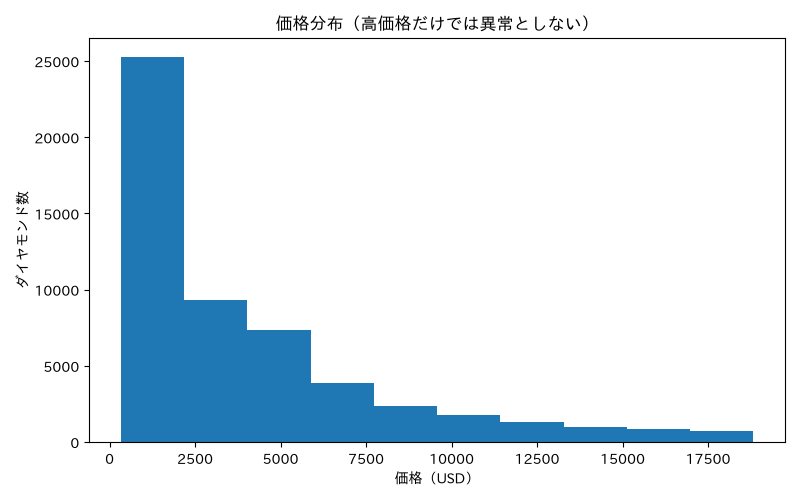

In [6]:
with phase('価格分布図'):
    show_chart(main, 'hist', 'price', None, '価格分布（高価格だけでは異常としない）', '価格（USD）', 'ダイヤモンド数')


図表検査: PNG bytes= 55415 ; missing glyph warnings= 0 ; title/xlabel/ylabel明記


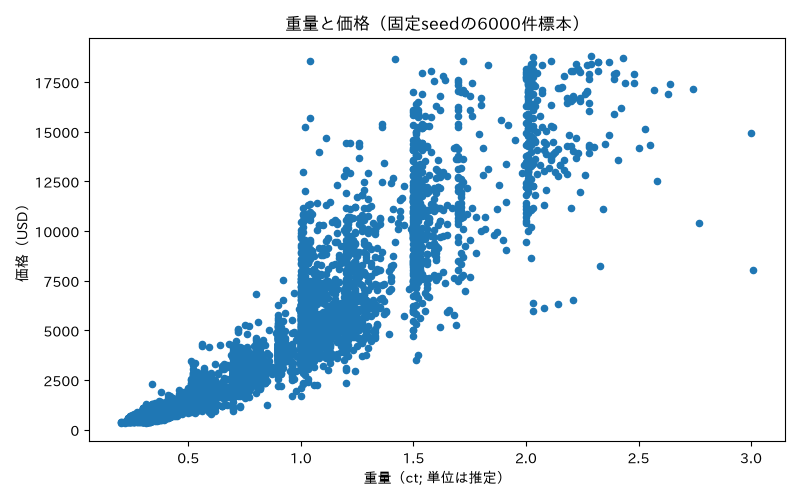

In [7]:
with phase('重量と価格図'):
    plot_sample = main.sample(min(6000,len(main)), random_state=2026)
    show_chart(plot_sample, 'scatter', 'carat', 'price', '重量と価格（固定seedの6000件標本）', '重量（ct; 単位は推定）', '価格（USD）')


図表検査: PNG bytes= 26265 ; missing glyph warnings= 0 ; title/xlabel/ylabel明記


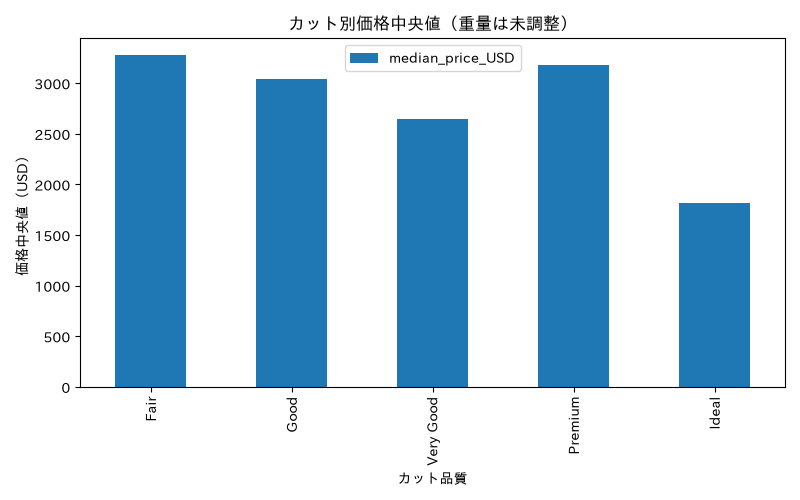

In [8]:
with phase('無調整カット図'):
    cut_plot = raw_quality['cut'].reset_index()
    show_chart(cut_plot, 'bar', 'cut', 'median_price_USD', 'カット別価格中央値（重量は未調整）', 'カット品質', '価格中央値（USD）')


## 初回モデルと感度分析
80/20固定分割（seed=2026）、価格は自然対数。重量の非線形性を3次Bスプラインで調整し、品質はダミー変数で扱う。対数R2は対数価格の分散説明率であってUSD価格の分散説明率ではない。寸法群は重量と強く共線的なので「独立した重要特徴」と断定せず、追加したときの検証誤差を比較する。

主解析の全件モデルで条件調整後の品質関連とHC3区間を算出する。感度分析は12仕様（スプライン自由度4/6/8 × 主解析/重複保持/寸法異常保持/価格0.5%裾除外）。主結果と同じ検証セットを用いた特徴群除去は説明的な追加寄与であり、特徴の因果的重要度ではない。


In [9]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from threadpoolctl import threadpool_limits
with phase('初回モデル比較・調整後関連'):
    model_frame = main.assign(logprice=np.log(main.price))
    train, test = train_test_split(model_frame, test_size=0.2, random_state=2026)
    quality_terms = {
        'cut': "C(cut, Treatment(reference='Fair'))",
        'color': "C(color, Treatment(reference='J'))",
        'clarity': "C(clarity, Treatment(reference='I1'))",
    }
    def weight_term(df_spline=6):
        return f'bs(np.log(carat), df={df_spline}, degree=3, lower_bound=np.log(0.2), upper_bound=np.log(5.01))'
    def quality_formula(df_spline=6, omit=None):
        return 'logprice ~ ' + weight_term(df_spline) + ' + ' + ' + '.join(v for k,v in quality_terms.items() if k!=omit)
    formulas = {
        '重量log直線': 'logprice ~ np.log(carat)',
        '重量スプライン': 'logprice ~ ' + weight_term(),
        '重量+品質': quality_formula(),
        '重量+品質+寸法': quality_formula() + ' + depth + table + np.log(x) + np.log(y) + np.log(z)',
        '品質のみ': 'logprice ~ ' + ' + '.join(quality_terms.values()),
    }
    fitted, predictions, score_rows = {}, {}, []
    with threadpool_limits(limits=2):
        for label, formula in formulas.items():
            fit = smf.ols(formula, data=train).fit()
            pred_log = np.asarray(fit.predict(test))
            smear = float(np.exp(fit.resid).mean())
            pred_usd = np.exp(pred_log) * smear
            fitted[label] = fit
            predictions[label] = pred_log
            score_rows.append({'モデル':label,'n_train':len(train),'n_test':len(test),
                'test_R2_logprice':r2_score(test.logprice,pred_log),
                'test_RMSE_logprice':float(np.sqrt(np.mean((test.logprice-pred_log)**2))),
                'test_R2_USD':r2_score(test.price,pred_usd),
                'test_MAE_USD':mean_absolute_error(test.price,pred_usd),
                'smearing_factor':smear})
        quality_fit = smf.ols(quality_formula(), data=model_frame).fit(cov_type='HC3')
        ablation_rows = []
        full_rmse = score_rows[2]['test_RMSE_logprice']
        for omitted in ['cut','color','clarity']:
            f = smf.ols(quality_formula(omit=omitted), data=train).fit()
            p = np.asarray(f.predict(test))
            rmse = float(np.sqrt(np.mean((test.logprice-p)**2)))
            ablation_rows.append({'除いた特徴群':omitted,'test_RMSE_logprice':rmse,'増加_logRMSE':rmse-full_rmse})
    model_scores = pd.DataFrame(score_rows)
    ablation = pd.DataFrame(ablation_rows)
    print('MODEL_SCORES=' + model_scores.to_json(orient='records',force_ascii=False))
    display(model_scores.round(5))
    print('BLOCK_ABLATION=' + ablation.to_json(orient='records',force_ascii=False))
    display(ablation.round(5))
    effect_rows = []
    cis = quality_fit.conf_int()
    for col, term in quality_terms.items():
        for level in variable_definitions[col]['order'].value:
            key = term + '[T.' + level + ']'
            coef = float(quality_fit.params.get(key, 0.0))
            lo, hi = (cis.loc[key].to_numpy() if key in cis.index else [0.,0.])
            effect_rows.append({'feature':col,'level':level,'vs_reference':variable_definitions[col]['order'].value[0],
                'adjusted_pct':100*np.expm1(coef),'HC3_lo_pct':100*np.expm1(lo),'HC3_hi_pct':100*np.expm1(hi)})
    effects = pd.DataFrame(effect_rows)
    print('ADJUSTED_EFFECTS=' + effects.to_json(orient='records',force_ascii=False))
    display(effects.round(3))
    ideal_pct = float(effects.query("feature=='cut' and level=='Ideal'").adjusted_pct.iloc[0])
    print('IDEAL_FAIR_ADJUSTED_PCT=' + repr(ideal_pct))
    print('QUALITY_LOG_R2=' + repr(float(model_scores.loc[model_scores['モデル']=='重量+品質','test_R2_logprice'].iloc[0])))
    print('解釈: 係数の%は同じ重量・他品質のモデル上の幾何平均価格比。算術平均価格差や因果効果ではない。HC3区間はモデル内不確実性のみ。対数R2とUSD R2を区別。smearingは訓練残差だけで算出しUSDへの逆変換バイアスを部分補正。')


MODEL_SCORES=[{"モデル":"重量log直線","n_train":43017,"n_test":10755,"test_R2_logprice":0.9327720844,"test_RMSE_logprice":0.2635643414,"test_R2_USD":0.8376111947,"test_MAE_USD":857.4004486227,"smearing_factor":1.035337262},{"モデル":"重量スプライン","n_train":43017,"n_test":10755,"test_R2_logprice":0.9358793828,"test_RMSE_logprice":0.2574012648,"test_R2_USD":0.8689795449,"test_MAE_USD":827.4906029212,"smearing_factor":1.0335464506},{"モデル":"重量+品質","n_train":43017,"n_test":10755,"test_R2_logprice":0.9852062934,"test_RMSE_logprice":0.1236375327,"test_R2_USD":0.9675489403,"test_MAE_USD":381.6243180955,"smearing_factor":1.0080254603},{"モデル":"重量+品質+寸法","n_train":43017,"n_test":10755,"test_R2_logprice":0.9853912557,"test_RMSE_logprice":0.1228621957,"test_R2_USD":0.9664843858,"test_MAE_USD":385.8027378012,"smearing_factor":1.0078826973},{"モデル":"品質のみ","n_train":43017,"n_test":10755,"test_R2_logprice":0.0729874298,"test_RMSE_logprice":0.9787113866,"test_R2_USD":0.0464588623,"test_MAE_USD":2903.5323746491,"smeari

,モデル,n_train,n_test,test_R2_logprice,test_RMSE_logprice,test_R2_USD,test_MAE_USD,smearing_factor
0,重量log直線,43017,10755,0.93277,0.26356,0.83761,857.40045,1.03534
1,重量スプライン,43017,10755,0.93588,0.25740,0.86898,827.49060,1.03355
2,重量+品質,43017,10755,0.98521,0.12364,0.96755,381.62432,1.00803
3,重量+品質+寸法,43017,10755,0.98539,0.12286,0.96648,385.80274,1.00788
4,品質のみ,43017,10755,0.07299,0.97871,0.04646,2903.53237,1.58271


,除いた特徴群,test_RMSE_logprice,増加_logRMSE
0,cut,0.12878,0.00514
1,color,0.17954,0.05590
2,clarity,0.22007,0.09643


,feature,level,vs_reference,adjusted_pct,HC3_lo_pct,HC3_hi_pct
0,cut,Fair,Fair,0.000,0.000,0.000
1,cut,Good,Fair,8.133,7.162,9.112
2,cut,Very Good,Fair,11.834,10.875,12.801
3,cut,Premium,Fair,14.823,13.835,15.819
4,cut,Ideal,Fair,17.994,16.987,19.009
5,color,J,J,0.000,0.000,0.000
6,color,I,J,14.364,13.666,15.066
7,color,H,J,28.436,27.686,29.190
8,color,G,J,41.489,40.684,42.298
9,color,F,J,51.152,50.270,52.039


In [10]:
from ai_data_scientist.sensitivity import SensitivityPlan, run_sensitivity
with phase('仕様感度分析'):
    sensitivity_details = []
    def sensitivity_analysis(subset, df_spline):
        pool = {'主解析':main, '重複保持':diamonds.loc[valid_dims], '寸法異常保持':base,
                '価格両端0.5%除外':main.loc[main.price.between(main.price.quantile(.005),main.price.quantile(.995))]}[subset]
        frame = pool.assign(logprice=np.log(pool.price))
        with threadpool_limits(limits=2):
            fit = smf.ols(quality_formula(df_spline=df_spline), data=frame).fit()
        key = quality_terms['cut'] + '[T.Ideal]'
        premium_pct = float(100*np.expm1(fit.params[key]))
        sensitivity_details.append({'subset':subset,'df_spline':df_spline,'n':len(frame),'ideal_fair_pct':premium_pct})
        return premium_pct
    sensitivity_plan = SensitivityPlan(parameter_grid={'subset':['主解析','重複保持','寸法異常保持','価格両端0.5%除外'], 'df_spline':[6,4,8]},max_runs=12)
    sensitivity_report = run_sensitivity(sensitivity_plan, sensitivity_analysis, stability_tolerance=.2)
    print('SENSITIVITY_REPORT=' + json.dumps(asdict(sensitivity_report),ensure_ascii=False))
    display(pd.DataFrame(sensitivity_details).round(4))
    print('stable=', sensitivity_report.stable, '; max_relative_deviation=', sensitivity_report.max_relative_deviation)
    print('判定対象はIdeal/Fairの調整後関連の大きさ。符号一致だけで全結果が安定とは主張しない。許容差20%は価格比の%差に対する相対偏差で事前指定。')
    assumption_status = {'duplicates':'tested','dimensions':'tested'}
    from dataclasses import replace
    assumptions_final = replace(assumptions, assumptions=tuple(replace(a,status=assumption_status.get(a.id,a.status)) for a in assumptions.assumptions))
    print('ANALYSIS_ASSUMPTION_MANIFEST_UPDATED=' + json.dumps(asdict(assumptions_final),ensure_ascii=False))
    print('ASSUMPTION_FINDINGS_UPDATED=', [asdict(f) for f in check_manifest(assumptions_final)])


SENSITIVITY_REPORT={"results": [{"specification": {"subset": "主解析", "df_spline": 6}, "value": 17.993759742784285}, {"specification": {"subset": "主解析", "df_spline": 4}, "value": 17.868760647573588}, {"specification": {"subset": "主解析", "df_spline": 8}, "value": 18.506006665531725}, {"specification": {"subset": "重複保持", "df_spline": 6}, "value": 17.90468999120135}, {"specification": {"subset": "重複保持", "df_spline": 4}, "value": 17.778520451657272}, {"specification": {"subset": "重複保持", "df_spline": 8}, "value": 18.422192884381396}, {"specification": {"subset": "寸法異常保持", "df_spline": 6}, "value": 17.989108872336235}, {"specification": {"subset": "寸法異常保持", "df_spline": 4}, "value": 17.864248099298806}, {"specification": {"subset": "寸法異常保持", "df_spline": 8}, "value": 18.499945601417046}, {"specification": {"subset": "価格両端0.5%除外", "df_spline": 6}, "value": 17.88814885178487}, {"specification": {"subset": "価格両端0.5%除外", "df_spline": 4}, "value": 17.776778182245394}, {"specification": {"subset": "価

,subset,df_spline,n,ideal_fair_pct
0,主解析,6,53772,17.9938
1,主解析,4,53772,17.8688
2,主解析,8,53772,18.5060
3,重複保持,6,53917,17.9047
4,重複保持,4,53917,17.7785
5,重複保持,8,53917,18.4222
6,寸法異常保持,6,53794,17.9891
7,寸法異常保持,4,53794,17.8642
8,寸法異常保持,8,53794,18.4999
9,価格両端0.5%除外,6,53247,17.8881


図表検査: PNG bytes= 29941 ; missing glyph warnings= 0 ; title/xlabel/ylabel明記


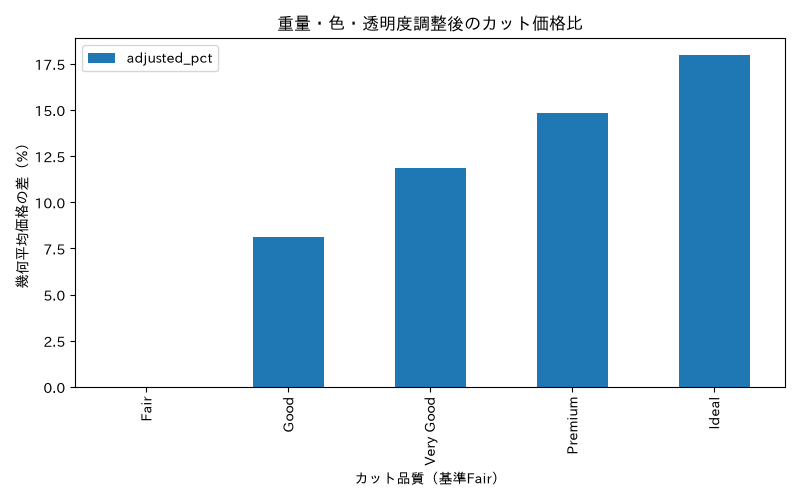

In [11]:
with phase('調整後カット価格比図'):
    cut_effects = effects.query("feature=='cut'").copy()
    show_chart(cut_effects, 'bar', 'level', 'adjusted_pct', '重量・色・透明度調整後のカット価格比', 'カット品質（基準Fair）', '幾何平均価格の差（%）')


## 反復依頼履歴

### 反復1 — 依頼原文
全体モデルのIdeal対Fair約18%という差を、すべての重量に共通する値と解釈してよいか確認してください。重量帯ごとに色・透明度と帯内重量を調整した差、比較群の件数、信頼区間を示し、重量と品質の交互作用を許したモデルの検証誤差も比較してください。疎な組合せや外挿は明示してください。

### 選定理由
初回の条件調整モデルは品質差を重量にかかわらず一定と仮定している。全体平均の約18%が重量帯で変わるなら結論の適用範囲が変わるため、追加価値がある。初回感度分析はスプライン・除外基準だけで、この仮定をまだ検証していない。

### 結果・証拠・残る限界の記録方法
直後のITERATION1_STRATA、交互作用RMSE、比較群件数を実行結果として残し、統合Insightから実行済み根拠を引用する。

In [12]:
with phase('反復1: 重量帯別の品質差・交互作用'):
    iteration1_request = '全体モデルのIdeal対Fair約18%という差を、すべての重量に共通する値と解釈してよいか確認してください。重量帯ごとに色・透明度と帯内重量を調整した差、比較群の件数、信頼区間を示し、重量と品質の交互作用を許したモデルの検証誤差も比較してください。疎な組合せや外挿は明示してください。'
    bands = [(0.2,.5,'0.2–<0.5'),(.5,1,'0.5–<1'),(1,1.5,'1–<1.5'),(1.5,2,'1.5–<2'),(2,5.02,'2–5.01')]
    strata_rows = []
    with threadpool_limits(limits=2):
        for low,high,label in bands:
            g = model_frame.loc[model_frame.carat.ge(low)&model_frame.carat.lt(high)]
            counts = g.cut.value_counts()
            if min(int(counts.get('Fair',0)),int(counts.get('Ideal',0))) < 50:
                print('帯',label,'はFair/Idealが50件未満で推定を保留:',counts.to_dict())
                continue
            f = smf.ols(quality_formula(df_spline=4),data=g).fit(cov_type='HC3')
            key = quality_terms['cut']+'[T.Ideal]'
            lo,hi=f.conf_int().loc[key].to_numpy()
            strata_rows.append({'重量帯_ct':label,'n':len(g),'n_Fair':int(counts['Fair']),'n_Ideal':int(counts['Ideal']),
                'ideal_fair_pct':100*np.expm1(f.params[key]),'HC3_lo_pct':100*np.expm1(lo),'HC3_hi_pct':100*np.expm1(hi)})
        interaction_terms = [f"I(np.log(carat) * ({c} == {level!r}))" for c in quality_terms for level in variable_definitions[c]['order'].value[1:]]
        interaction_formula = quality_formula() + ' + ' + ' + '.join(interaction_terms)
        interaction_fit = smf.ols(interaction_formula,data=train).fit()
        assert np.linalg.matrix_rank(interaction_fit.model.exog) == interaction_fit.model.exog.shape[1]
        interaction_prediction = np.asarray(interaction_fit.predict(test))
        interaction_log_rmse = float(np.sqrt(np.mean((test.logprice-interaction_prediction)**2)))
    strata = pd.DataFrame(strata_rows)
    print('ITERATION1_STRATA=' + strata.to_json(orient='records',force_ascii=False))
    display(strata.round(4))
    print('INTERACTION_LOG_RMSE=' + repr(interaction_log_rmse))
    print('ADDITIVE_LOG_RMSE=' + repr(float(model_scores.loc[2,'test_RMSE_logprice'])))
    print('比較カテゴリの同時組合せの共通支持は全帯で保証されない。帯内OLSでも未観測品質の組合せへ外挿しうる。')
    support = pd.crosstab(pd.cut(model_frame.carat,[.199,.5,1,1.5,2,5.02],right=False),model_frame.cut)
    display(support)
    print('残る限界: 帯内で色・透明度を同時調整しても販売条件等の未観測差は残る。交互作用は追加検証セットで新しく確認した仮説で、事前仮説ではない。')


ITERATION1_STRATA=[{"重量帯_ct":"0.2–<0.5","n":17608,"n_Fair":112,"n_Ideal":8716,"ideal_fair_pct":2.7589586059,"HC3_lo_pct":-2.6261976579,"HC3_hi_pct":8.4419353029},{"重量帯_ct":"0.5–<1","n":17180,"n_Fair":678,"n_Ideal":6908,"ideal_fair_pct":19.9514818685,"HC3_lo_pct":18.6863561468,"HC3_hi_pct":21.2300930752},{"重量帯_ct":"1–<1.5","n":12787,"n_Fair":487,"n_Ideal":4207,"ideal_fair_pct":24.9285713156,"HC3_lo_pct":23.1729253831,"HC3_hi_pct":26.7092413564},{"重量帯_ct":"1.5–<2","n":4068,"n_Fair":167,"n_Ideal":1141,"ideal_fair_pct":19.3116565587,"HC3_lo_pct":16.1817732631,"HC3_hi_pct":22.5258574642},{"重量帯_ct":"2–5.01","n":2129,"n_Fair":153,"n_Ideal":512,"ideal_fair_pct":16.664802376,"HC3_lo_pct":13.6889396521,"HC3_hi_pct":19.7185597393}]
INTERACTION_LOG_RMSE=0.12036363924699653
ADDITIVE_LOG_RMSE=0.1236375326926601
比較カテゴリの同時組合せの共通支持は全帯で保証されない。帯内OLSでも未観測品質の組合せへ外挿しうる。
残る限界: 帯内で色・透明度を同時調整しても販売条件等の未観測差は残る。交互作用は追加検証セットで新しく確認した仮説で、事前仮説ではない。


,重量帯_ct,n,n_Fair,n_Ideal,ideal_fair_pct,HC3_lo_pct,HC3_hi_pct
0,0.2–<0.5,17608,112,8716,2.7590,-2.6262,8.4419
1,0.5–<1,17180,678,6908,19.9515,18.6864,21.2301
2,1–<1.5,12787,487,4207,24.9286,23.1729,26.7092
3,1.5–<2,4068,167,1141,19.3117,16.1818,22.5259
4,2–5.01,2129,153,512,16.6648,13.6889,19.7186


cut,Fair,Good,Ideal,Premium,Very Good
carat,,,,,
"[0.199, 0.5)",112,1201,8716,4027,3552
"[0.5, 1.0)",678,1788,6908,3554,4252
"[1.0, 1.5)",487,1270,4207,3931,2892
"[1.5, 2.0)",167,420,1141,1417,923
"[2.0, 5.02)",153,209,512,807,448


### 反復2 — 依頼原文
0.5ct未満ではFairが112件しかなく、調整後差の区間に0が含まれました。全体のカット差と重量帯別の結論が疎な組合せへの外挿で生じていないか、色・透明度が同じで重量が近いFairとIdealの共通支持層だけで価格比を比較してください。また、深さの再計算値が1パーセントポイント超ずれる行を除いて、寸法追加の結論とカット価格比への影響を確認してください。

### 選定理由
反復1で0.5ct未満の差が不確かであり、全体の約18%を全重量に共通する差とする解釈は撤回する。Fairの少ない帯の組合せ外挿を検査する。また意味的検査でdepth再計算差>1ppが77件あったため、寸法群の追加寄与という結論に影響するか検査する。

### 実行上の修正
交互作用をカテゴリ全水準のlog重量傾きで表現した初回は、共通log重量がスプライン基底と重複してstatsmodelsのrank-deficient警告が出た。基準水準を除いた差分傾きへ置換し、行列フルランクをassertして再実行した。分析式の設計問題でありJupytermindの不具合ではない。

### 証拠
直前のITERATION1_STRATAと、直後のITERATION2_MATCHED/ITERATION2_DEPTH_CHECK。結果と限界は根拠付き統合Insightにも記録する。

In [13]:
with phase('反復2: 共通支持・寸法整合性'):
    iteration2_request = '0.5ct未満ではFairが112件しかなく、調整後差の区間に0が含まれました。全体のカット差と重量帯別の結論が疎な組合せへの外挿で生じていないか、色・透明度が同じで重量が近いFairとIdealの共通支持層だけで価格比を比較してください。また、深さの再計算値が1パーセントポイント超ずれる行を除いて、寸法追加の結論とカット価格比への影響を確認してください。'
    matched_rows = []
    rng_match = np.random.default_rng(2026)
    for width in [.02,.05]:
        match_frame = model_frame.loc[model_frame.cut.isin(['Fair','Ideal'])].copy()
        match_frame['bin'] = np.floor((match_frame.carat+.000001)/width).astype(int)
        matched_table = match_frame.groupby(['bin','color','clarity','cut']).logprice.agg(['mean','size']).unstack('cut')
        matched_table = matched_table.dropna()
        matched_table = matched_table.loc[(matched_table['size']['Fair']>=2)&(matched_table['size']['Ideal']>=2)]
        def matched_summary(table,label):
            if len(table)<2:
                print('共通支持不足:',width,label,'層数=',len(table))
                return
            difference = (table['mean']['Ideal']-table['mean']['Fair']).to_numpy()
            nf=table['size']['Fair'].to_numpy(); ni=table['size']['Ideal'].to_numpy()
            weight=nf*ni/(nf+ni)
            estimate=float(100*np.expm1(np.average(difference,weights=weight)))
            boot=[]
            for _ in range(1000):
                ids=rng_match.integers(0,len(table),len(table))
                boot.append(100*np.expm1(np.average(difference[ids],weights=weight[ids])))
            lo,hi=np.quantile(boot,[.025,.975])
            matched_rows.append({'幅_ct':width,'範囲':label,'共通層数':len(table),'Fair件数':int(nf.sum()),'Ideal件数':int(ni.sum()),'ideal_fair_pct':estimate,'層bootstrap_lo_pct':lo,'層bootstrap_hi_pct':hi})
        matched_summary(matched_table,'全重量')
        small=matched_table.loc[matched_table.index.get_level_values('bin')*width < .5]
        matched_summary(small,'0.5ct未満')
    matched_results=pd.DataFrame(matched_rows)
    print('ITERATION2_MATCHED=' + matched_results.to_json(orient='records',force_ascii=False))
    display(matched_results.round(4))
    consistent = model_frame.loc[depth_error.reindex(model_frame.index).le(1)].copy()
    consistent_train=train.loc[train.index.intersection(consistent.index)]
    consistent_test=test.loc[test.index.intersection(consistent.index)]
    geometry_check=[]
    with threadpool_limits(limits=2):
        consistent_full = smf.ols(quality_formula(),data=consistent).fit()
        consistent_ideal_pct=float(100*np.expm1(consistent_full.params[quality_terms['cut']+'[T.Ideal]']))
        for label in ['重量+品質','重量+品質+寸法']:
            fit=smf.ols(formulas[label],data=consistent_train).fit()
            pred=np.asarray(fit.predict(consistent_test))
            usd=np.exp(pred)*float(np.exp(fit.resid).mean())
            geometry_check.append({'モデル':label,'n_train':len(consistent_train),'n_test':len(consistent_test),'log_RMSE':float(np.sqrt(np.mean((consistent_test.logprice-pred)**2))),'USD_MAE':mean_absolute_error(consistent_test.price,usd)})
    print('ITERATION2_DEPTH_CHECK=' + json.dumps({'n_consistent':len(consistent),'excluded':len(model_frame)-len(consistent),'ideal_fair_pct':consistent_ideal_pct,'models':geometry_check},ensure_ascii=False))
    print('残る限界: 共通支持推定は比較可能な層だけを対象とし全データとは母集団が違う。重量はビン幅以内で異なり、未観測販売条件も一致させられない。bootstrapは層の再標本化でモデル選択不確実性や市場外挿は含まない。深さ1pp基準は丸め誤差より大きい検査閾値で測定誤りの確定ではない。')


ITERATION2_MATCHED=[{"幅_ct":0.02,"範囲":"全重量","共通層数":217,"Fair件数":962,"Ideal件数":4347,"ideal_fair_pct":21.2760935868,"層bootstrap_lo_pct":19.6871969431,"層bootstrap_hi_pct":22.8034201565},{"幅_ct":0.02,"範囲":"0.5ct未満","共通層数":19,"Fair件数":41,"Ideal件数":875,"ideal_fair_pct":2.107049746,"層bootstrap_lo_pct":-0.9904885813,"層bootstrap_hi_pct":5.9971786699},{"幅_ct":0.05,"範囲":"全重量","共通層数":231,"Fair件数":1166,"Ideal件数":8300,"ideal_fair_pct":22.1049865174,"層bootstrap_lo_pct":20.6650243207,"層bootstrap_hi_pct":23.4052120425},{"幅_ct":0.05,"範囲":"0.5ct未満","共通層数":23,"Fair件数":63,"Ideal件数":2089,"ideal_fair_pct":7.0383679024,"層bootstrap_lo_pct":0.0759119907,"層bootstrap_hi_pct":15.2655425017}]
ITERATION2_DEPTH_CHECK={"n_consistent": 53695, "excluded": 77, "ideal_fair_pct": 17.947269913254473, "models": [{"モデル": "重量+品質", "n_train": 42957, "n_test": 10738, "log_RMSE": 0.12367914500494585, "USD_MAE": 381.5266423892541}, {"モデル": "重量+品質+寸法", "n_train": 42957, "n_test": 10738, "log_RMSE": 0.1227263014305368, "USD_MAE": 38

,幅_ct,範囲,共通層数,Fair件数,Ideal件数,ideal_fair_pct,層bootstrap_lo_pct,層bootstrap_hi_pct
0,0.02,全重量,217,962,4347,21.2761,19.6872,22.8034
1,0.02,0.5ct未満,19,41,875,2.1070,-0.9905,5.9972
2,0.05,全重量,231,1166,8300,22.1050,20.6650,23.4052
3,0.05,0.5ct未満,23,63,2089,7.0384,0.0759,15.2655


### 反復3 — 依頼原文
初回の特徴群除去では透明度、色、カットの順に追加説明力が大きくなりました。この順位と品質追加による誤差改善が分割seedを変えても維持されるか確認してください。重量の丸い境界0.5、1.0、1.5、2.0ctで価格の段差を許す仕様も比較し、全体カット価格比の仕様依存性、検証重量帯ごとの誤差、寸法追加の小さな改善の不確実性を示してください。

### 選定理由
反復2では共通支持に限った全体差は約21–22%、小重量帯は2–7%で幅に依存し、強い一律の差は主張できない。一方、主結論の特徴群順位は1分割のみであり、散布図の丸い重量近辺の集積に対して連続スプラインだけでは段差を見落とす可能性がある。寸法追加のlog誤差差が小さいため不確実性も確認する。

### 結果・証拠
直後のITERATION3_SEEDS/RANK/BAND_ERRORS/PAIRED_BOOTSTRAPとTHRESHOLD_IDEAL_PCTを保存し、統合Insightで根拠を参照する。

In [14]:
with phase('反復3: 分割・丸い重量境界・誤差の不確実性'):
    iteration3_request='初回の特徴群除去では透明度、色、カットの順に追加説明力が大きくなりました。この順位と品質追加による誤差改善が分割seedを変えても維持されるか確認してください。重量の丸い境界0.5、1.0、1.5、2.0ctで価格の段差を許す仕様も比較し、全体カット価格比の仕様依存性、検証重量帯ごとの誤差、寸法追加の小さな改善の不確実性を示してください。'
    threshold_formula=quality_formula()+' + '+' + '.join(f'I(carat >= {v})' for v in [.5,1.,1.5,2.])
    seed_rows=[]; rank_rows=[]
    with threadpool_limits(limits=2):
        for seed in [2026,17,42]:
            tr,te=train_test_split(model_frame,test_size=.2,random_state=seed)
            score={}
            for label,formula in [('重量のみ',formulas['重量スプライン']),('重量+品質',quality_formula()),('重量+品質+境界',threshold_formula)]:
                f=smf.ols(formula,data=tr).fit()
                p=np.asarray(f.predict(te))
                score[label]=float(np.sqrt(np.mean((te.logprice-p)**2)))
                seed_rows.append({'seed':seed,'モデル':label,'log_RMSE':score[label]})
                if seed==2026 and label=='重量+品質+境界':
                    threshold_prediction=p
            for omit in ['cut','color','clarity']:
                f=smf.ols(quality_formula(omit=omit),data=tr).fit()
                p=np.asarray(f.predict(te))
                rank_rows.append({'seed':seed,'除去':omit,'増加_logRMSE':float(np.sqrt(np.mean((te.logprice-p)**2)))-score['重量+品質']})
        threshold_full=smf.ols(threshold_formula,data=model_frame).fit(cov_type='HC3')
        assert np.linalg.matrix_rank(threshold_full.model.exog)==threshold_full.model.exog.shape[1]
    threshold_ideal_pct=float(100*np.expm1(threshold_full.params[quality_terms['cut']+'[T.Ideal]']))
    print('ITERATION3_SEEDS=' + pd.DataFrame(seed_rows).to_json(orient='records',force_ascii=False))
    print('ITERATION3_RANK=' + pd.DataFrame(rank_rows).to_json(orient='records',force_ascii=False))
    print('THRESHOLD_IDEAL_PCT=' + repr(threshold_ideal_pct))
    display(pd.DataFrame(seed_rows).round(5)); display(pd.DataFrame(rank_rows).round(5))
    band_errors=[]
    test_usd=np.exp(predictions['重量+品質'])*float(np.exp(fitted['重量+品質'].resid).mean())
    for low,high,label in bands:
        mask=test.carat.ge(low)&test.carat.lt(high)
        band_errors.append({'重量帯_ct':label,'n_test':int(mask.sum()),'quality_log_RMSE':float(np.sqrt(np.mean((test.logprice.to_numpy()[mask]-predictions['重量+品質'][mask])**2))),'threshold_log_RMSE':float(np.sqrt(np.mean((test.logprice.to_numpy()[mask]-threshold_prediction[mask])**2))),'quality_USD_MAE':mean_absolute_error(test.price.to_numpy()[mask],test_usd[mask])})
    print('ITERATION3_BAND_ERRORS=' + json.dumps(band_errors,ensure_ascii=False))
    rng_boot=np.random.default_rng(2026)
    log_y=test.logprice.to_numpy()
    bootstrap_rows=[]
    for newer,older in [('重量+品質','重量スプライン'),('重量+品質+寸法','重量+品質')]:
        delta=(log_y-predictions[older])**2-(log_y-predictions[newer])**2
        boot=np.empty(1000)
        for i in range(1000):
            boot[i]=delta[rng_boot.integers(0,len(delta),len(delta))].mean()
        lo,hi=np.quantile(boot,[.025,.975])
        bootstrap_rows.append({'比較':newer+' vs '+older,'MSE改善':float(delta.mean()),'paired_bootstrap_lo':lo,'paired_bootstrap_hi':hi})
    print('ITERATION3_PAIRED_BOOTSTRAP=' + json.dumps(bootstrap_rows,ensure_ascii=False))
    print('残る限界: seed変更は同じデータ内の分割感度で外部検証ではない。反復で同じ検証データを参照しており最終的な未使用評価ではない。段差項は説明的仕様比較で、閾値を越えた因果効果や最適モデルの確定を意味しない。2ct以上は少なく誤差も大きい。bootstrap区間は学習済みモデル固定で、再学習の不確実性は含めない。')


ITERATION3_SEEDS=[{"seed":2026,"モデル":"重量のみ","log_RMSE":0.2574012648},{"seed":2026,"モデル":"重量+品質","log_RMSE":0.1236375327},{"seed":2026,"モデル":"重量+品質+境界","log_RMSE":0.119733649},{"seed":17,"モデル":"重量のみ","log_RMSE":0.2575578096},{"seed":17,"モデル":"重量+品質","log_RMSE":0.1262487558},{"seed":17,"モデル":"重量+品質+境界","log_RMSE":0.1225550426},{"seed":42,"モデル":"重量のみ","log_RMSE":0.2564453389},{"seed":42,"モデル":"重量+品質","log_RMSE":0.1283662094},{"seed":42,"モデル":"重量+品質+境界","log_RMSE":0.1247401009}]
ITERATION3_RANK=[{"seed":2026,"除去":"cut","増加_logRMSE":0.0051377244},{"seed":2026,"除去":"color","増加_logRMSE":0.0559036811},{"seed":2026,"除去":"clarity","増加_logRMSE":0.0964345234},{"seed":17,"除去":"cut","増加_logRMSE":0.0048045222},{"seed":17,"除去":"color","増加_logRMSE":0.0548160999},{"seed":17,"除去":"clarity","増加_logRMSE":0.0948428846},{"seed":42,"除去":"cut","増加_logRMSE":0.0043278405},{"seed":42,"除去":"color","増加_logRMSE":0.0537618416},{"seed":42,"除去":"clarity","増加_logRMSE":0.0940813628}]
THRESHOLD_IDEAL_PCT=18.31390156728180

,seed,モデル,log_RMSE
0,2026,重量のみ,0.25740
1,2026,重量+品質,0.12364
2,2026,重量+品質+境界,0.11973
3,17,重量のみ,0.25756
4,17,重量+品質,0.12625
5,17,重量+品質+境界,0.12256
6,42,重量のみ,0.25645
7,42,重量+品質,0.12837
8,42,重量+品質+境界,0.12474


,seed,除去,増加_logRMSE
0,2026,cut,0.00514
1,2026,color,0.05590
2,2026,clarity,0.09643
3,17,cut,0.00480
4,17,color,0.05482
5,17,clarity,0.09484
6,42,cut,0.00433
7,42,color,0.05376
8,42,clarity,0.09408


図表検査: PNG bytes= 31437 ; missing glyph warnings= 0 ; title/xlabel/ylabel明記


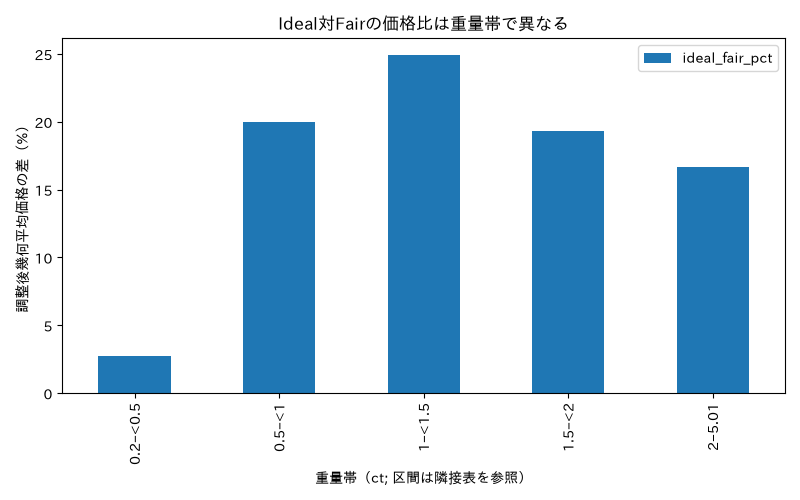

In [15]:
with phase('重量帯別カット差の図'):
    show_chart(strata, 'bar', '重量帯_ct', 'ideal_fair_pct', 'Ideal対Fairの価格比は重量帯で異なる', '重量帯（ct; 区間は隣接表を参照）', '調整後幾何平均価格の差（%）')


図表検査: PNG bytes= 30953 ; missing glyph warnings= 0 ; title/xlabel/ylabel明記


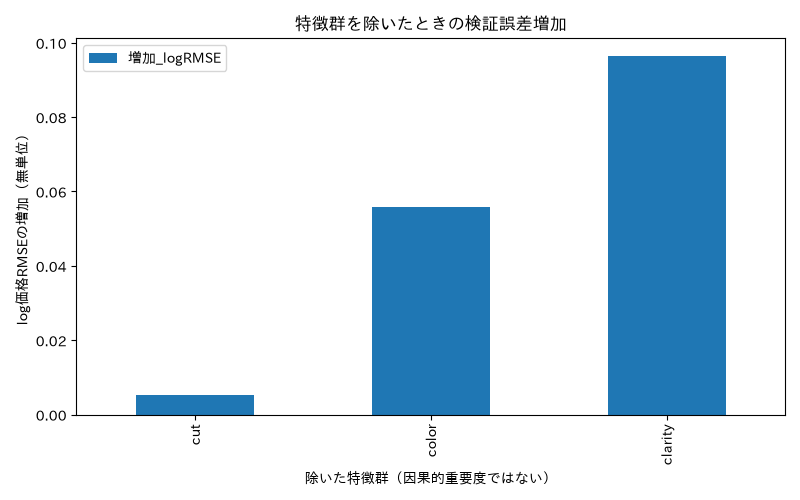

In [16]:
with phase('品質特徴群の追加説明力の図'):
    show_chart(ablation, 'bar', '除いた特徴群', '増加_logRMSE', '特徴群を除いたときの検証誤差増加', '除いた特徴群（因果的重要度ではない）', 'log価格RMSEの増加（無単位）')


## 反復の終了判断と残る限界
3回の追加依頼を実行した。全体の重量関連、品質の追加説明力、透明度>色>カットというモデル内の特徴群順位は確認できた。カット価格比は重量帯・共通支持母集団に依存するため「すべての石で約18%」という表現を採用しない。小重量帯のFairが少ないことは同じデータでモデルを増やしても解消できず、未測定販売条件や市場時点も復元できない。最大3回に到達し、追加モデルを探索して有意な結論を得ようとすることは避ける。外部/未使用データ検証を必要とする限界を残して終了する。


## 使用したJupytermindモジュール
このNotebookで直接importし、直接呼び出したAPIだけを列挙する。ライブラリ内部の間接利用は使用済みに含めない。

| モジュール | 直接呼出し（クラス構築を含む） | 目的 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | slug検証、指定保存先、安定データパス、直列Notebook書込み |
| ai_data_scientist.language_router | detect_language | 日本語での報告 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行/書込みフェーズ・取消確認・終了状態 |
| ai_data_scientist.ingestion | SourceSpec, ingest | 原本CSVを上限確認つきで読込 |
| ai_data_scientist.cleaning | clean_dataset | 重複・欠測の除去行数記録 |
| ai_data_scientist.eda | explore | 欠測、型、カテゴリ分布、基本統計 |
| ai_data_scientist.stats_analysis | correlation | Pearson係数と日本語解釈 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 単位・定義・出典・未解決定義 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 非因果の適用範囲と前提リスク |
| ai_data_scientist.data_quality | detect_anomalies | 意味的制約逸脱 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 有限12仕様の安定性判定 |
| ai_data_scientist.visualization | render_chart, build_image_output | 日本語図の生成・PNG MIME永続化 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight（EvidenceMissingErrorを明示処理） | 実行出力の値の抽出・根拠つきInsight |
| ai_data_scientist.notebook_audit | audit_notebook(visual_audit=True) | Notebook実行・根拠・図表の監査 |

KaggleApi、pandas、NumPy、scipy、statsmodels、scikit-learn、matplotlib、nbformat、threadpoolctlは外部ライブラリであり、Jupytermind利用数に含めない。mcp_gateway、dataset_validation、anomaly_detection、ML拡張、独立データvalidate_anomaliesは直接利用していない。ネイティブMCP transportの呼出しはCLIが行い、kernel内に適合MCPClientがないためrun_and_recordは非適用。外部API取込はSDKで取得したローカル原本をingestしており、ingestのAPI fetcher経由ではない。正規分布のz-scoreで高価格を誤りとする方法は価格の歪みのため採用しない。


## Jupytermind改善候補
候補はコードを修正せず、再現検査と回避策をNotebookに残す。Kaggle SDKのdataset_view非搭載とmetadataのinfoラッパー、statsmodelsの交互作用ランク不足は別の問題であり、この候補には含めない。Copilot CLI・ベンチマークランナーの問題をJupytermindの不具合として扱わない。

| ID・分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |
|---|---|---|---|---|---|---|
| JM-01 可視化の可読性/レイアウト不足 | visualization.render_chartの既定6.4×4.8図で、barに長い重量帯ラベルと日本語xlabelを指定 | ラベル全体がPNG内に入り読める | xlabelのbounding box下端が負のpixel座標となり、PNGでxlabelが切れる | 単位・軸の意味が見えない。メタデータとbyte-densityのvisual auditだけでは切れを検出できない | 描画呼出しをrc_context(figure.autolayout=True, figsize=(8,5))で囲む。提出用6図は回避策を適用 | 重量帯別図、描画準備、改善候補再現検査。JUPYTERMIND_CANDIDATE_LOGのxlabel_bottom_pixelとPNG SHA。data/jupytermind-layout-reproduction.png |
| JM-02 evidence出力形式互換性不足 | 実行済み相関セルのprint出力に実際のPEARSON値がある状態で、record_insightへそのexecution_count/valueを渡す | nbformat stream.textも根拠出力として解決する | _find_evidence_cellはdata MIMEだけを検索しEvidenceMissingError | MCPネイティブ実行のprintのみの値ではInsightを記録できない | 計算済み根拠をtext/plain MIMEにdisplayしてからextract_cited_value/record_insightする。根拠内容を捏造しない | 初回探索・相関、改善候補再現検査、統合根拠出力、最終監査。JM-02ログのstream_value、evidence_execution_count、例外クラス |

再現検査は期待されたEvidenceMissingErrorだけを捕捉し、その他のエラーは隠さない。図表監査のbyte-densityは目視やテキスト配置の完全な代替ではないため、実際のMCP表示でも回避後の図を確認する。


### JM-03 — 日本語フォント初期化とrc_contextの整合性（可視化不具合候補）
再現条件: 冷スタート後、日本語図をrc_context内で初回render_chartする。最初の図は読めるが、context終了でfont.familyが戻った後、2番目の図をrender_chartするとGlyph missing警告が出る。期待: render_chartが日本語図の度に有効な日本語フォントを保証する。実際: _japanese_font_appliedという一度限りのflagが残り、現在のrcParamsでフォントが戻っていることを再確認しない。影響: 再実行中の散布図が欠落グリフ検査でRuntimeErrorとなりrunはfailedになった。回避策: 外部japanize_matplotlib.japanize()をrc_contextの外で明示適用してから描画し、全図でフォントを維持する。Jupytermind内部のフォント初期化stateとMatplotlib contextの相互作用であり、CLI/Kaggle/runnerとは別問題。
関係セル: 描画準備、重量と価格図、改善候補再現検査。ログ: Notebook.metadata.diamonds_execution_attemptsとJUPYTERMIND_CANDIDATE_LOG.JM-03（warning数と代表3警告）。再現検査はfont.familyを一時的に戻すだけでmodule内部flagを改変しない。最終図はグリフ警告0を要求する。


In [17]:
from ai_data_scientist.insight_engine import extract_cited_value, record_insight, EvidenceMissingError
with phase('Jupytermind改善候補の再現検査'):
    notebook_snapshot=nbformat.read(handle.notebook_path,as_version=4)
    correlation_cell=next(c for c in notebook_snapshot.cells if c.cell_type=='code' and 'PEARSON=' in c.source)
    stream_text=''.join(o.get('text','') for o in correlation_cell.outputs if o.output_type=='stream')
    stream_value=extract_cited_value({'output':stream_text},r'PEARSON=([0-9.eE+-]+)')
    try:
        record_insight(handle,'stream出力互換性の再現用候補（成功時だけ追記）',correlation_cell.execution_count,stream_value,'associational',language='ja')
    except EvidenceMissingError:
        stream_issue_confirmed=True
        print('JM-02再現: 実行済みstreamにcited_valueが存在するがrecord_insightはEvidenceMissingError。根拠なしのInsightは保存していない。')
    else:
        stream_issue_confirmed=False
        raise AssertionError('想定していたstream非対応が再現しないため改善候補記載を更新してください')
    with matplotlib.rc_context({'figure.autolayout':False,'figure.figsize':(6.4,4.8)}):
        baseline_png=render_chart(strata,kind='bar',x='重量帯_ct',y='ideal_fair_pct',title='Ideal対Fairの価格比は重量帯で異なる',xlabel='重量帯（ct; 区間は隣接表を参照）',ylabel='調整後幾何平均価格の差（%）')
        fig,ax=plt.subplots()
        try:
            strata.plot(kind='bar',x='重量帯_ct',y='ideal_fair_pct',ax=ax)
            ax.set_title('Ideal対Fairの価格比は重量帯で異なる')
            ax.set_xlabel('重量帯（ct; 区間は隣接表を参照）')
            ax.set_ylabel('調整後幾何平均価格の差（%）')
            fig.canvas.draw()
            xlabel_y0=float(ax.xaxis.label.get_window_extent(fig.canvas.get_renderer()).y0)
            print('JM-01再現: デフォルト描画のxlabel下端px=',xlabel_y0,'; canvas範囲はy>=0')
        finally:
            plt.close(fig)
    assert xlabel_y0<0, '既定レイアウトの切れが再現しないため候補を更新してください'
    with phase('改善候補PNG書込み',writing=True):
        baseline_path=data_dir/'jupytermind-layout-reproduction.png'
        baseline_path.write_bytes(baseline_png)
    diagnostic_log={'JM-01':{'xlabel_bottom_pixel':xlabel_y0,'baseline_sha256':hashlib.sha256(baseline_png).hexdigest(),'artifact':str(baseline_path),'workaround':'matplotlib.rc_context figure.autolayout=True, figsize=(8,5)'},'JM-02':{'stream_value':stream_value,'evidence_execution_count':correlation_cell.execution_count,'expected_exception':'EvidenceMissingError','workaround':'IPython display text/plain MIME; extract_cited_valueからrecord_insight'}}

    with matplotlib.rc_context({'font.family':['DejaVu Sans']}):
        with warnings.catch_warnings(record=True) as font_caught:
            warnings.simplefilter('always')
            render_chart(main.head(100),kind='scatter',x='carat',y='price',title='日本語再現',xlabel='重量',ylabel='価格')
        font_glyph_warnings=[str(w.message) for w in font_caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
    assert font_glyph_warnings, '一度適用済みフォントflagとrc_contextの問題が再現しない'
    diagnostic_log['JM-03']={'glyph_warning_count':len(font_glyph_warnings),'sample':font_glyph_warnings[:3],'condition':'日本語を1回render済み; rc_contextでfont.familyをDejaVu Sansに戻して日本語render','workaround':'japanize_matplotlib.japanizeをrc_contextの外側で明示しIPAexGothic設定を保持'}
    print('JM-03再現: font設定をcontextで戻すとrender_chartは再適用せずmissing glyph warnings=',len(font_glyph_warnings))
    print('JUPYTERMIND_CANDIDATE_LOG=' + json.dumps(diagnostic_log,ensure_ascii=False))


JM-02再現: 実行済みstreamにcited_valueが存在するがrecord_insightはEvidenceMissingError。根拠なしのInsightは保存していない。
JM-01再現: デフォルト描画のxlabel下端px= -39.04212239583334 ; canvas範囲はy>=0
JM-03再現: font設定をcontextで戻すとrender_chartは再適用せずmissing glyph warnings= 9
JUPYTERMIND_CANDIDATE_LOG={"JM-01": {"xlabel_bottom_pixel": -39.04212239583334, "baseline_sha256": "e25802a2315af0a627f9d541e7d009c2307d1181bcd0d94374e93d541acccca0", "artifact": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-05-diamonds/data/jupytermind-layout-reproduction.png", "workaround": "matplotlib.rc_context figure.autolayout=True, figsize=(8,5)"}, "JM-02": {"stream_value": "0.921542058659105", "evidence_execution_count": 4, "expected_exception": "EvidenceMissingError", "workaround": "IPython display text/plain MIME; extract_cited_valueからrecord_insight"}, "JM-03": {"glyph_warning_count": 9, "sample": ["Glyph 20385 (\\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.", "Glyph 26684 (\\N{CJK UNIFIED IDEOGRAPH-

## 統合Insightと再実行・監査
以下の統合根拠セルは計算済み変数をtext/plain MIMEに出力する。根拠値はその保存済み出力からextract_cited_valueで抽出し、record_insightで根拠を検証して記録する。再実行時には古い生成Insightを削除して根拠countを更新し、重複・古いcountを残さない。最終セルはNotebookとPNGをvisual_audit=Trueで監査し、失敗ならfailed、成功ならcompletedを記録する。

再実行手順: 同じ環境とKaggle認証を利用し、kernelを再起動してコードセルを上から実行する。毎回SDKで再検索・再取得し、原本SHA-256が変われば停止する。秘密情報をコードに埋め込まず、環境に設定済みの認証を用いる。データ・分析manifest、全バージョン、実行セルID/count、フェーズログ、監査、状態はNotebook.metadata.diamonds_analysisにも保存する。固定seedの数値が再現し、取得日時のみ更新される設計である。


In [18]:
with phase('統合根拠出力・報告用結果'):
    model_map=model_scores.set_index('モデル')
    evidence_metrics={
        'raw_rows':int(len(raw)), 'main_rows':int(len(main)), 'duplicates_removed':int(dedup_report.rows_removed), 'dimension_excluded':int((~valid_base).sum()),
        'pearson':float(pearson.statistic),'spearman':float(spearman.statistic),
        'weight_log_R2':float(model_map.loc['重量スプライン','test_R2_logprice']),
        'quality_log_R2':float(model_map.loc['重量+品質','test_R2_logprice']),
        'quality_USD_R2':float(model_map.loc['重量+品質','test_R2_USD']),
        'weight_USD_MAE':float(model_map.loc['重量スプライン','test_MAE_USD']),
        'quality_USD_MAE':float(model_map.loc['重量+品質','test_MAE_USD']),
        'fair_median_USD':float(raw_quality['cut'].loc['Fair','median_price_USD']),
        'ideal_median_USD':float(raw_quality['cut'].loc['Ideal','median_price_USD']),
        'ideal_adjusted_pct':ideal_pct,
        'ideal_small_pct':float(strata.iloc[0].ideal_fair_pct),
        'ideal_small_lo_pct':float(strata.iloc[0].HC3_lo_pct),
        'ideal_small_hi_pct':float(strata.iloc[0].HC3_hi_pct),
        'ideal_1to1point5_pct':float(strata.iloc[2].ideal_fair_pct),
        'matched_global_002_pct':float(matched_results.iloc[0].ideal_fair_pct),
        'matched_small_002_pct':float(matched_results.iloc[1].ideal_fair_pct),
        'sensitivity_stable':bool(sensitivity_report.stable),
        'sensitivity_max_relative_deviation':float(sensitivity_report.max_relative_deviation),
        'sensitivity_min_pct':float(min(r.value for r in sensitivity_report.results)),
        'sensitivity_max_pct':float(max(r.value for r in sensitivity_report.results)),
        'threshold_ideal_pct':threshold_ideal_pct,
        'clarity_ablation_logRMSE':float(ablation.set_index('除いた特徴群').loc['clarity','増加_logRMSE']),
        'color_ablation_logRMSE':float(ablation.set_index('除いた特徴群').loc['color','増加_logRMSE']),
        'cut_ablation_logRMSE':float(ablation.set_index('除いた特徴群').loc['cut','増加_logRMSE']),
        'geometry_USD_MAE':float(model_map.loc['重量+品質+寸法','test_MAE_USD']),
        'tail_2ct_USD_MAE':float(band_errors[-1]['quality_USD_MAE']),
        'depth_disagreement_removed':int(len(model_frame)-len(consistent)),
    }
    evidence_text=json.dumps(evidence_metrics,ensure_ascii=False,indent=2)
    display({'text/plain':evidence_text},raw=True)
    print('根拠出力は計算済み変数から生成し、手入力した結果値は含まない。')
    insight_specs=[
        ('main_rows',f'分析対象は原本{len(raw):,}行から重複{dedup_report.rows_removed}行、主解析の寸法フラグ{(~valid_base).sum()}行を除いた{len(main):,}行。欠測除外は{complete_report.rows_removed}行。高価格・大重量だけでは削除していない。価格はKaggle辞書でUSD、寸法はmmと確認済み。重量ctとtableの%は推定、時点・母集団・測定過程・ライセンスは未確認である。','descriptive'),
        ('pearson',f'重量が価格差を最も大きく説明する。重量と価格のPearson相関は{pearson.statistic:.4f}、Spearmanは{spearman.statistic:.4f}。重量スプラインだけで検証log価格R2={evidence_metrics["weight_log_R2"]:.4f}。これは重量を増やす因果効果ではなく、このファイル内の関連である。','associational'),
        ('quality_USD_R2',f'重量だけでは説明しきれない品質差がある。色・透明度・カットを加えると検証log価格R2は{evidence_metrics["weight_log_R2"]:.4f}から{evidence_metrics["quality_log_R2"]:.4f}へ、USD価格R2は{evidence_metrics["quality_USD_R2"]:.4f}となる。USDの平均絶対誤差は{evidence_metrics["weight_USD_MAE"]:.1f}から{evidence_metrics["quality_USD_MAE"]:.1f} USDへ減少。log分散説明率とUSD分散説明率を混同しない。','associational'),
        ('clarity_ablation_logRMSE',f'この仕様の品質群の追加説明力は透明度>色>カット。各群を除くと検証log価格RMSEが順に{evidence_metrics["clarity_ablation_logRMSE"]:.4f}、{evidence_metrics["color_ablation_logRMSE"]:.4f}、{evidence_metrics["cut_ablation_logRMSE"]:.4f}増加し、seed=2026/17/42でも順位を維持した。共線性と分布に依存する特徴群除去評価であり、因果的重要度や品質1段階の共通価格効果ではない。','associational'),
        ('ideal_adjusted_pct',f'無調整のIdeal中央値{evidence_metrics["ideal_median_USD"]:.0f} USDはFairの{evidence_metrics["fair_median_USD"]:.0f} USDより低いが、小重量の構成差がある。同じ重量・色・透明度の加法モデルではIdeal/Fairの幾何平均価格差は約{ideal_pct:.2f}%で符号が逆転する。仕様感度12通りでは{evidence_metrics["sensitivity_min_pct"]:.2f}–{evidence_metrics["sensitivity_max_pct"]:.2f}%。stable={sensitivity_report.stable}、max_relative_deviation={sensitivity_report.max_relative_deviation:.6f}（約{100*sensitivity_report.max_relative_deviation:.2f}%、許容20%）。段差仕様は{threshold_ideal_pct:.2f}%。構成差・条件調整を無視した単純ランキングは避ける。','associational'),
        ('ideal_small_pct',f'反復1で一律約18%という解釈は撤回した。0.2–<0.5ct帯のIdeal/Fair調整差は{evidence_metrics["ideal_small_pct"]:.2f}%、HC3 95%区間は{evidence_metrics["ideal_small_lo_pct"]:.2f}–{evidence_metrics["ideal_small_hi_pct"]:.2f}%で0を含む。Fair={int(strata.iloc[0].n_Fair)}件に対しIdeal={int(strata.iloc[0].n_Ideal)}件で比較が疎。1–<1.5ctは{evidence_metrics["ideal_1to1point5_pct"]:.2f}%。交互作用仕様の検証logRMSEは{interaction_log_rmse:.5f}（加法{float(model_map.loc["重量+品質","test_RMSE_logprice"]):.5f}）。品質差は重量帯依存で、区間はモデル条件下の不確実性である。','associational'),
        ('matched_global_002_pct',f'反復2の同じ色・透明度、重量幅0.02ctの共通支持層では全体Ideal/Fair差は{evidence_metrics["matched_global_002_pct"]:.2f}%（{int(matched_results.iloc[0]["共通層数"])}層）、小重量帯は{evidence_metrics["matched_small_002_pct"]:.2f}%でbootstrap区間に0を含む。幅0.05ctでは小重量差が変わるので小重量の正の差を頑健とはしない。これは共通支持の別母集団で全体OLS18%と同じestimandではない。深さ差>1ppの{len(model_frame)-len(consistent)}行を除いても全体調整差は{consistent_ideal_pct:.2f}%で主要方向は変わらなかった。','associational'),
        ('geometry_USD_MAE',f'寸法は重量と強く相関し、独立寄与を過大解釈しない。寸法群追加のlog誤差改善は小さく、USD MAEは{evidence_metrics["quality_USD_MAE"]:.1f}から{evidence_metrics["geometry_USD_MAE"]:.1f} USDへ悪化した。反復3のpaired bootstrapではlog MSE改善は正だったが、尺度が違うためUSD予測改善とは主張しない。深さ整合性除外後もUSD MAEの改善は確認できない。','associational'),
        ('tail_2ct_USD_MAE',f'反復3では丸い重量境界を許すと3seedで全体log誤差が少し改善したが、1.5–<2ctでは悪化する。品質追加と特徴群順位という主結論は維持。2ct以上は検証{band_errors[-1]["n_test"]}件でUSD MAE={evidence_metrics["tail_2ct_USD_MAE"]:.1f}と大きく、全体MAEだけで大型石の精度を保証できない。同じ検証データを反復参照した探索的評価であり、未使用外部データでの性能とは異なる。','associational'),
    ]


根拠出力は計算済み変数から生成し、手入力した結果値は含まない。


{
  "raw_rows": 53940,
  "main_rows": 53772,
  "duplicates_removed": 146,
  "dimension_excluded": 22,
  "pearson": 0.921542058659105,
  "spearman": 0.9629276573567681,
  "weight_log_R2": 0.9358793827809633,
  "quality_log_R2": 0.9852062934245668,
  "quality_USD_R2": 0.9675489403073931,
  "weight_USD_MAE": 827.4906029212383,
  "quality_USD_MAE": 381.62431809554795,
  "fair_median_USD": 3282.0,
  "ideal_median_USD": 1813.0,
  "ideal_adjusted_pct": 17.993759742784285,
  "ideal_small_pct": 2.758958605909665,
  "ideal_small_lo_pct": -2.626197657933873,
  "ideal_small_hi_pct": 8.44193530285223,
  "ideal_1to1point5_pct": 24.928571315568533,
  "matched_global_002_pct": 21.2760935868181,
  "matched_small_002_pct": 2.1070497460111053,
  "sensitivity_stable": true,
  "sensitivity_max_relative_deviation": 0.02846803169931496,
  "sensitivity_min_pct": 17.776778182245394,
  "sensitivity_max_pct": 18.506006665531725,
  "threshold_ideal_pct": 18.313901567281803,
  "clarity_ablation_logRMSE": 0.0964345

分析対象は原本53,940行から重複146行、主解析の寸法フラグ22行を除いた53,772行。欠測除外は0行。高価格・大重量だけでは削除していない。価格はKaggle辞書でUSD、寸法はmmと確認済み。重量ctとtableの%は推定、時点・母集団・測定過程・ライセンスは未確認である。

```evidence
{"execution_count":18,"cited_value":"53772","claim_type":"descriptive"}
```

重量が価格差を最も大きく説明する。重量と価格のPearson相関は0.9215、Spearmanは0.9629。重量スプラインだけで検証log価格R2=0.9359。これは重量を増やす因果効果ではなく、このファイル内の関連である。

```evidence
{"execution_count":18,"cited_value":"0.921542058659105","claim_type":"associational"}
```

重量だけでは説明しきれない品質差がある。色・透明度・カットを加えると検証log価格R2は0.9359から0.9852へ、USD価格R2は0.9675となる。USDの平均絶対誤差は827.5から381.6 USDへ減少。log分散説明率とUSD分散説明率を混同しない。

```evidence
{"execution_count":18,"cited_value":"0.9675489403073931","claim_type":"associational"}
```

この仕様の品質群の追加説明力は透明度>色>カット。各群を除くと検証log価格RMSEが順に0.0964、0.0559、0.0051増加し、seed=2026/17/42でも順位を維持した。共線性と分布に依存する特徴群除去評価であり、因果的重要度や品質1段階の共通価格効果ではない。

```evidence
{"execution_count":18,"cited_value":"0.09643452340288124","claim_type":"associational"}
```

無調整のIdeal中央値1813 USDはFairの3282 USDより低いが、小重量の構成差がある。同じ重量・色・透明度の加法モデルではIdeal/Fairの幾何平均価格差は約17.99%で符号が逆転する。仕様感度12通りでは17.78–18.51%。stable=True、max_relative_deviation=0.028468（約2.85%、許容20%）。段差仕様は18.31%。構成差・条件調整を無視した単純ランキングは避ける。

```evidence
{"execution_count":18,"cited_value":"17.993759742784285","claim_type":"associational"}
```

反復1で一律約18%という解釈は撤回した。0.2–<0.5ct帯のIdeal/Fair調整差は2.76%、HC3 95%区間は-2.63–8.44%で0を含む。Fair=112件に対しIdeal=8716件で比較が疎。1–<1.5ctは24.93%。交互作用仕様の検証logRMSEは0.12036（加法0.12364）。品質差は重量帯依存で、区間はモデル条件下の不確実性である。

```evidence
{"execution_count":18,"cited_value":"2.758958605909665","claim_type":"associational"}
```

反復2の同じ色・透明度、重量幅0.02ctの共通支持層では全体Ideal/Fair差は21.28%（217層）、小重量帯は2.11%でbootstrap区間に0を含む。幅0.05ctでは小重量差が変わるので小重量の正の差を頑健とはしない。これは共通支持の別母集団で全体OLS18%と同じestimandではない。深さ差>1ppの77行を除いても全体調整差は17.95%で主要方向は変わらなかった。

```evidence
{"execution_count":18,"cited_value":"21.2760935868181","claim_type":"associational"}
```

寸法は重量と強く相関し、独立寄与を過大解釈しない。寸法群追加のlog誤差改善は小さく、USD MAEは381.6から385.8 USDへ悪化した。反復3のpaired bootstrapではlog MSE改善は正だったが、尺度が違うためUSD予測改善とは主張しない。深さ整合性除外後もUSD MAEの改善は確認できない。

```evidence
{"execution_count":18,"cited_value":"385.80273780118216","claim_type":"associational"}
```

反復3では丸い重量境界を許すと3seedで全体log誤差が少し改善したが、1.5–<2ctでは悪化する。品質追加と特徴群順位という主結論は維持。2ct以上は検証414件でUSD MAE=1876.8と大きく、全体MAEだけで大型石の精度を保証できない。同じ検証データを反復参照した探索的評価であり、未使用外部データでの性能とは異なる。

```evidence
{"execution_count":18,"cited_value":"1876.7542036670447","claim_type":"associational"}
```

In [ ]:
from ai_data_scientist.notebook_audit import audit_notebook
from importlib.metadata import version
with phase('根拠つきInsightと実行メタデータの書込み',writing=True):
    def remove_generated(nb):
        nb.cells=[c for c in nb.cells if not c.metadata.get('generated_insight',False)]
    pm.enqueue_write(handle,remove_generated)
    snap=nbformat.read(handle.notebook_path,as_version=4)
    evidence_cell=next(c for c in snap.cells if c.metadata.get('role')=='consolidated-evidence')
    actual_text='\n'.join(o.get('data',{}).get('text/plain','') for o in evidence_cell.outputs)
    assert json.loads(actual_text)==evidence_metrics
    for key,text,claim_type in insight_specs:
        cited=extract_cited_value({'output':actual_text},r'"'+key+r'": ([0-9.eE+\-]+)')
        record_insight(handle,text,evidence_cell.execution_count,cited,claim_type,language='ja')
        def tag_latest(nb):
            nb.cells[-1].metadata['generated_insight']=True
            nb.cells[-1].metadata['evidence_cell_id']=evidence_cell.id
        pm.enqueue_write(handle,tag_latest)
    def finalize_metadata(nb):
        final_cell=next(c for c in nb.cells if c.metadata.get('role')=='final-audit')
        nb.cells=[c for c in nb.cells if c.id!=final_cell.id]+[final_cell]
        prior_codes=[c for c in nb.cells[:-1] if c.cell_type=='code']
        counts=[c.execution_count for c in prior_codes]
        assert all(isinstance(n,int) for n in counts)
        assert len(counts)==len(set(counts)) and counts==sorted(counts), '上からの実行順とcountが不整合'
        nb.metadata['diamonds_analysis']={
            'run_id':RUN_ID,'provenance':provenance,'data_definition':asdict(definition_manifest),
            'analysis_assumptions':asdict(assumptions_final),'sensitivity':asdict(sensitivity_report),
            'iterations':[iteration1_request,iteration2_request,iteration3_request],
            'jupytermind_improvement_candidates':diagnostic_log,
            'source_evidence_cells':[{'id':c.id,'execution_count':c.execution_count,'first_line':c.source.splitlines()[0]} for c in prior_codes],
            'versions':{p:version(p) for p in ['kaggle','pandas','numpy','scipy','statsmodels','scikit-learn','matplotlib','nbformat','threadpoolctl']},
            'execution_route':'Jupyter MCP execute_cell; no terminal/subprocess/agent',
            'reexecution_requirement':'kernelをrestartし、全codeセルを上からexecute_cellで実行; SHA一致・実行順を検査',
        }
    pm.enqueue_write(handle,finalize_metadata)
with phase('最終Notebook・図表監査'):
    audit_report=audit_notebook(handle.notebook_path,visual_audit=True)
    print('NOTEBOOK_AUDIT=' + json.dumps({**asdict(audit_report),'ok':audit_report.ok},ensure_ascii=False))
    if not audit_report.ok:
        raise RuntimeError('Notebook監査に未解決エラーがあります')
lifecycle.mark_completed(RUN_ID)
print('LIFECYCLE_COMPLETION=' + json.dumps(asdict(lifecycle.get_run_status(RUN_ID)),ensure_ascii=False))
with phase('監査・ライフサイクルログ永続化',writing=True):
    def persist_status(nb):
        nb.metadata['diamonds_analysis']['notebook_audit']={**asdict(audit_report),'ok':audit_report.ok,'visual_audit':True}
        nb.metadata['diamonds_analysis']['phase_log']=phase_log.copy()
        nb.metadata['diamonds_analysis']['status_during_log_write']=asdict(lifecycle.get_run_status(RUN_ID))
    pm.enqueue_write(handle,persist_status)
quiescent_status=lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
assert quiescent_status.state=='completed' and quiescent_status.active_cell_executions==0 and quiescent_status.pending_notebook_writes==0 and quiescent_status.locks_held==0
print('QUIESCENT_STATUS=' + json.dumps(asdict(quiescent_status),ensure_ascii=False))

with phase('実測完了状態の保存',writing=True):
    def persist_quiescence(nb):
        nb.metadata['diamonds_analysis']['lifecycle']=asdict(quiescent_status)
        nb.metadata['diamonds_analysis']['lifecycle_snapshot_timing']='前のログ書込み完了後の実測値を保存'
        nb.metadata['diamonds_analysis']['phase_log']=phase_log.copy()
    pm.enqueue_write(handle,persist_quiescence)
print('最終状態:', asdict(lifecycle.get_run_status(RUN_ID)))
